# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|      Sulaiman Faiz Tsaqib        |    5054251048   |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

In [2]:
# Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
data = pd.read_csv('WineQT.csv')
display(data.head())
data.info()
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


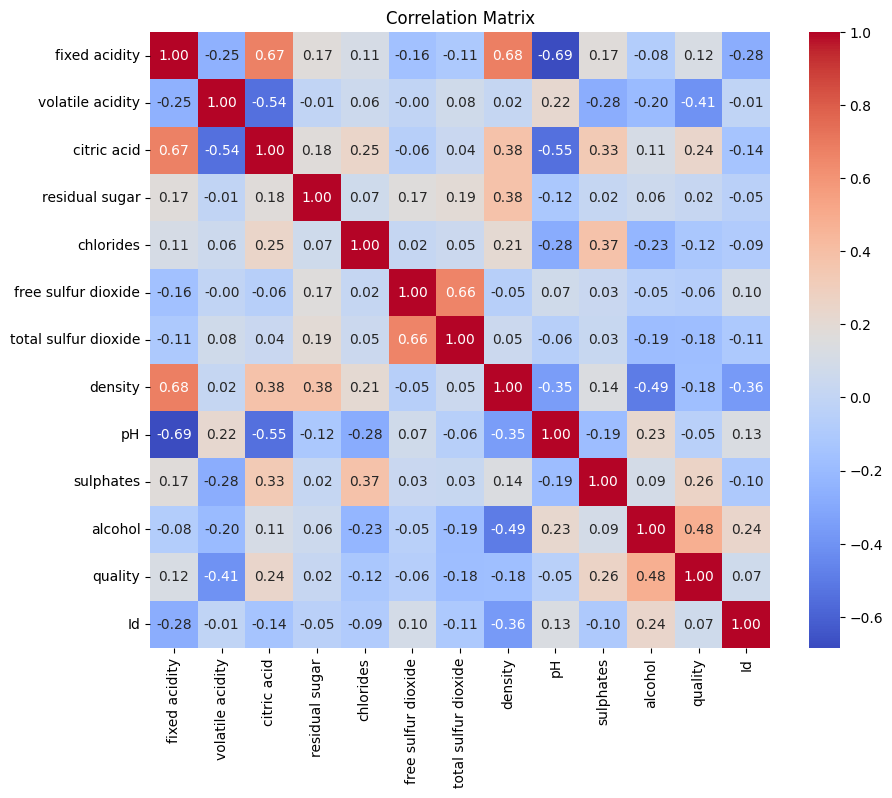

In [3]:
# Tampilkan Korelasi Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

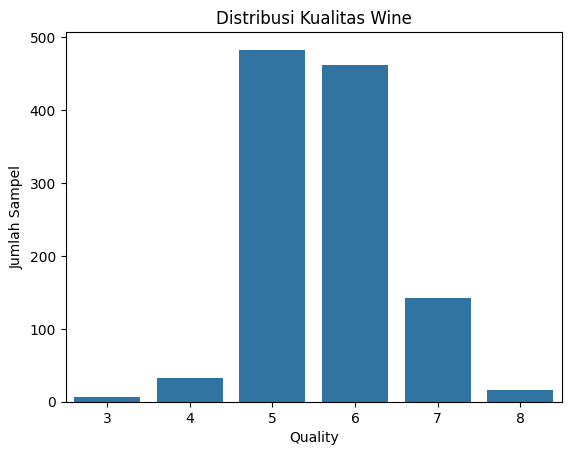

In [4]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
sns.countplot(x='quality', data=data)
plt.title('Distribusi Kualitas Wine')
plt.xlabel('Quality')
plt.ylabel('Jumlah Sampel')
plt.show()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [5]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
print('Missing values:', data.isnull().sum().sum())
print('Duplicate rows:', data.duplicated().sum())

# Kolom 'Id' hanya identifier, tidak relevan sebagai fitur
data = data.drop(columns=['Id']).drop_duplicates().reset_index(drop=True)
data.shape

Missing values: 0
Duplicate rows: 0


(1018, 12)

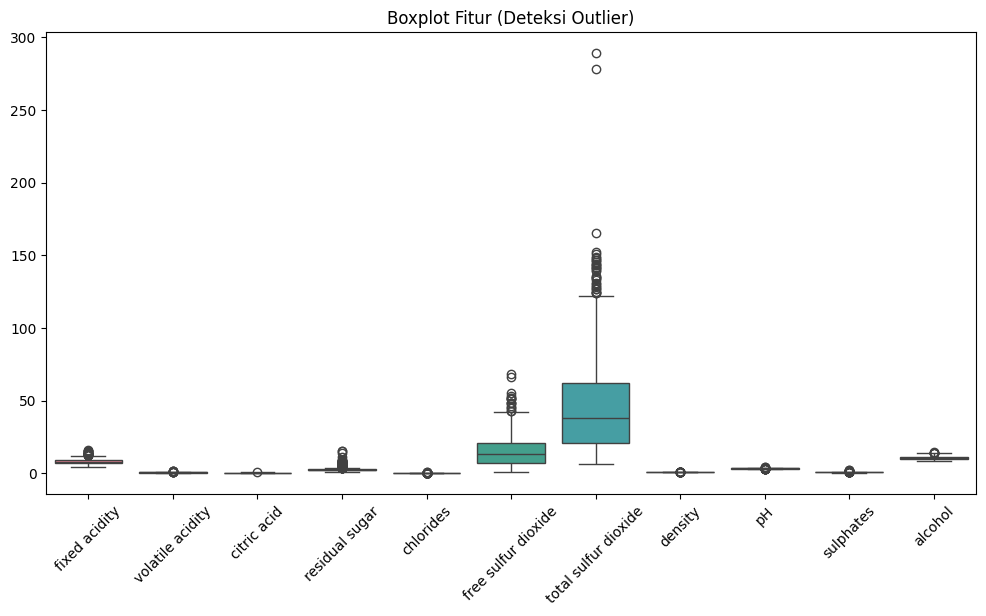

In [6]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
plt.figure(figsize=(12, 6))
sns.boxplot(data=data.drop(columns=['quality']))
plt.xticks(rotation=45)
plt.title('Boxplot Fitur (Deteksi Outlier)')
plt.show()

In [7]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
# -> scaler baru di-fit pada cell split (setelah train_test_split) agar tidak terjadi data leakage
scaler = StandardScaler()

# 3. Eksperimen Model KNN


In [8]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.
X = data.drop(columns=['quality'])
y = data['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []
for k in [1, 3, 5, 7, 9]:
    for metric in ['euclidean', 'manhattan']:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train_scaled, y_train)
        results.append({
            'k': k,
            'metric': metric,
            'train_acc': knn.score(X_train_scaled, y_train),
            'test_acc': knn.score(X_test_scaled, y_test)
        })

results_df = pd.DataFrame(results)
results_df

,k,metric,train_acc,test_acc
0,1,euclidean,1.000000,0.514706
1,1,manhattan,1.000000,0.514706
2,3,euclidean,0.734644,0.509804
3,3,manhattan,0.729730,0.470588
4,5,euclidean,0.678133,0.558824
5,5,manhattan,0.687961,0.480392
6,7,euclidean,0.654791,0.568627
7,7,manhattan,0.664619,0.553922
8,9,euclidean,0.647420,0.578431
9,9,manhattan,0.651106,0.544118


# 4. Evaluasi Model


Model terbaik: k=9, metric=euclidean
Accuracy : 0.5784
Precision: 0.5544
Recall   : 0.5784
F1-Score : 0.5627
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.67      0.66      0.66        87
           6       0.53      0.65      0.58        82
           7       0.47      0.33      0.39        24
           8       0.00      0.00      0.00         3

    accuracy                           0.58       204
   macro avg       0.28      0.27      0.27       204
weighted avg       0.55      0.58      0.56       204



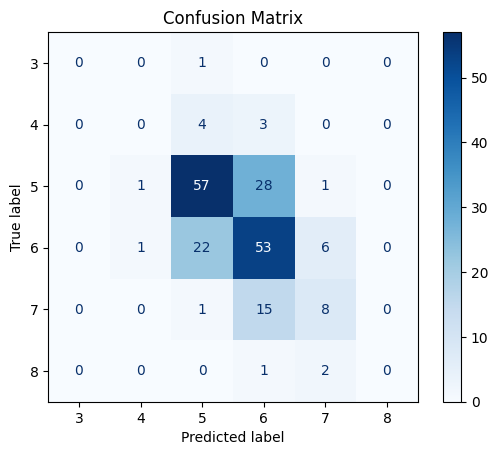

In [9]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
best = results_df.loc[results_df['test_acc'].idxmax()]
best_k, best_metric = int(best['k']), best['metric']
print(f'Model terbaik: k={best_k}, metric={best_metric}')

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test_scaled)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique())).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

**Test accuracy per k dan metric:**

| k | euclidean | manhattan |
|---|-----------|-----------|
| 1 | 0.515 | 0.515 |
| 3 | 0.510 | 0.471 |
| 5 | 0.559 | 0.480 |
| 7 | 0.569 | 0.554 |
| 9 | **0.578** | 0.544 |

Model terbaik: **k=9, euclidean** (test accuracy 0.578, F1 0.563).

- **k kecil (k=1)**: train acc 1.0 vs test acc 0.515 -> overfitting. Makin besar k, test acc naik -> model lebih general.
- **Metric**: euclidean konsisten >= manhattan di semua k setelah scaling.
- **Confusion matrix**: kelas mayoritas (quality 5, 6) diprediksi cukup baik, kelas minoritas (3, 4, 8) gagal total (precision/recall 0) karena sampelnya sedikit -> class imbalance.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan**: KNN k=9 + euclidean terbaik (acc 57.8%), tapi model masih lemah di kelas minoritas akibat data imbalance.

**Saran**: coba k lebih besar, tangani imbalance (SMOTE/gabung kelas), bandingkan dengan/tanpa outlier removal.